Training Accuracy: 85.95%


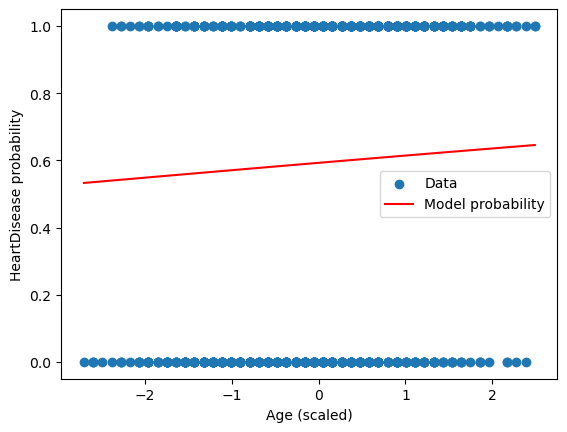

TypeError: 'float' object is not callable

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 1. Load the CSV
data = pd.read_csv("C:/Users/hp/Desktop/Everything/Work/Projects/classification problems/heart.csv")# Tab-separated


# 2. Preprocessing
# Convert categorical columns to numeric
data['Sex'] = data['Sex'].map({'M': 0, 'F': 1})
data['ChestPainType'] = data['ChestPainType'].map({'ATA':0, 'NAP':1, 'ASY':2, 'TA':3})
data['RestingECG'] = data['RestingECG'].map({'Normal':0, 'ST':1, 'LVH':2})
data['ExerciseAngina'] = data['ExerciseAngina'].map({'N':0, 'Y':1})
data['ST_Slope'] = data['ST_Slope'].map({'Up':0, 'Flat':1, 'Down':2})

# Features and target
X = data.drop(['HeartDisease'], axis=1).values
y = data['HeartDisease'].values

# Feature scaling
X = (X - X.mean(axis=0)) / X.std(axis=0)

# 3. Logistic Regression from scratch
class LogisticRegressionScratch:
    def __init__(self, learning_rate=0.1, iterations=1000):
        self.lr = learning_rate
        self.iterations = iterations
        self.theta = None

    def sigmoid(self, z):
        return 1 / (1 + np.exp(-z))

    def fit(self, X, y):
        m, n = X.shape
        X = np.c_[np.ones((m,1)), X]  # Add bias term
        self.theta = np.zeros(n+1)
        
        for _ in range(self.iterations):
            z = np.dot(X, self.theta)
            h = self.sigmoid(z)
            gradient = (1/m) * np.dot(X.T, (h - y))
            self.theta -= self.lr * gradient

    def predict_proba(self, X):
        m = X.shape[0]
        X = np.c_[np.ones((m,1)), X]
        return self.sigmoid(np.dot(X, self.theta))

    def predict(self, X, threshold=0.5):
        return (self.predict_proba(X) >= threshold).astype(int)

# 4. Train model
model = LogisticRegressionScratch(learning_rate=0.5, iterations=5000)
model.fit(X, y)

# 5. Test the model
y_pred = model.predict(X)
accuracy = (y_pred == y).mean()
print(f"Training Accuracy: {accuracy*100:.2f}%")

# 6. Plot probability of first feature (Age) vs HeartDisease probability
X_plot = np.linspace(X[:,0].min(), X[:,0].max(), 100).reshape(-1,1)
# Prepare a fake X with all features mean except Age
X_mean = X.mean(axis=0)
X_plot_full = np.tile(X_mean, (100,1))
X_plot_full[:,0] = X_plot[:,0]  # Replace Age column
y_prob = model.predict_proba(X_plot_full)

plt.scatter(X[:,0], y, label="Data")
plt.plot(X_plot[:,0], y_prob, color='red', label="Model probability")
plt.xlabel("Age (scaled)")
plt.ylabel("HeartDisease probability")
plt.legend()
plt.show()
print(model.lr())
# 7. Input for prediction
new_input = input("Enter values for features (Age, Sex[0=M,1=F], ChestPainType[0-3], RestingBP, Cholesterol, FastingBS, RestingECG[0-2], MaxHR, ExerciseAngina[0-1], Oldpeak, ST_Slope[0-2]) separated by comma: ")
new_input = np.array([float(x) for x in new_input.split(",")])

# Scale the input

new_input_scaled = (new_input - X.mean(axis=0)) / X.std(axis=0)
pred = model.predict(new_input_scaled.reshape(1,-1))
print(f"Predicted HeartDisease: {'Yes' if pred[0]==1 else 'No'}")


In [6]:
pd.head()

AttributeError: module 'pandas' has no attribute 'head'

In [10]:
print(data.columns)

Index(['Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease'], dtype='object')


Training Accuracy: 85.95%


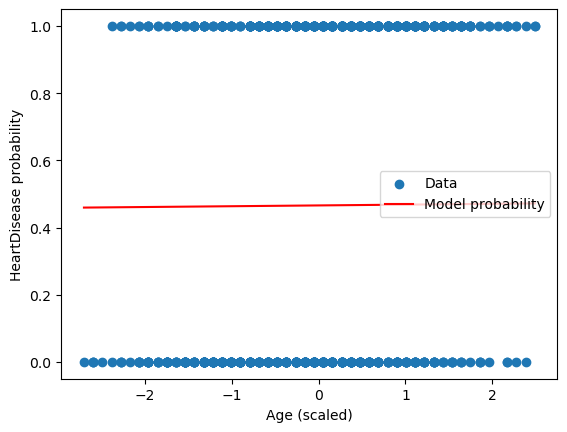

Enter values for features (Age, Sex[0=M,1=F], ChestPainType[0-3], RestingBP, Cholesterol, FastingBS, RestingECG[0-2], MaxHR, ExerciseAngina[0-1], Oldpeak, ST_Slope[0-2]) separated by comma:  45 , 0 , 2, 160,293,0,1,172,0,1.0,2,


ValueError: could not convert string to float: ''

In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


data = pd.read_csv("C:/Users/hp/Desktop/Everything/Work/Projects/classification problems/heart.csv")


data['Sex'] = data['Sex'].map({'M':0, 'F':1})
data['ChestPainType'] = data['ChestPainType'].map({'ATA':0, 'NAP':1, 'ASY':2, 'TA':3})
data['RestingECG'] = data['RestingECG'].map({'Normal':0, 'ST':1, 'LVH':2})
data['ExerciseAngina'] = data['ExerciseAngina'].map({'N':0, 'Y':1})
data['ST_Slope'] = data['ST_Slope'].map({'Up':0, 'Flat':1, 'Down':2})


X = data.drop(['HeartDisease'], axis=1).values
y = data['HeartDisease'].values

# 4. Feature scaling
X_mean = X.mean(axis=0)
X_std = X.std(axis=0)
X = (X - X_mean) / X_std

# 5. Logistic Regression from scratch
class LogisticRegressionScratch:
    def __init__(self, learning_rate=0.1, iterations=1000):
        self.lr = learning_rate
        self.iterations = iterations
        self.theta = None

    def sigmoid(self, z):
        return 1 / (1 + np.exp(-z))

    def fit(self, X, y):
        m, n = X.shape
        X = np.c_[np.ones((m,1)), X]  # Add bias term
        self.theta = np.zeros(n+1)
        
        for _ in range(self.iterations):
            z = np.dot(X, self.theta)
            h = self.sigmoid(z)
            gradient = (1/m) * np.dot(X.T, (h - y))
            self.theta -= self.lr * gradient

    def predict_proba(self, X):
        m = X.shape[0]
        X = np.c_[np.ones((m,1)), X]  # Add bias term
        return self.sigmoid(np.dot(X, self.theta))

    def predict(self, X, threshold=0.5):
        return (self.predict_proba(X) >= threshold).astype(int)

# 6. Train model
model = LogisticRegressionScratch(learning_rate=0.5, iterations=5000)
model.fit(X, y)

# 7. Evaluate
y_pred = model.predict(X)
accuracy = (y_pred == y).mean()
print(f"Training Accuracy: {accuracy*100:.2f}%")

# 8. Plot probability vs Age
X_plot = np.linspace(X[:,0].min(), X[:,0].max(), 100).reshape(-1,1)
X_mean_copy = np.tile(X_mean, (100,1))
X_plot_full = X_mean_copy.copy()
X_plot_full[:,0] = X_plot[:,0]  # replace Age column
X_plot_full_scaled = (X_plot_full - X_mean) / X_std  # scale again
y_prob = model.predict_proba(X_plot_full_scaled)

plt.scatter(X[:,0], y, label="Data")
plt.plot(X_plot[:,0], y_prob, color='red', label="Model probability")
plt.xlabel("Age (scaled)")
plt.ylabel("HeartDisease probability")
plt.legend()
plt.show()

# 9. Input for prediction
new_input = input("Enter values for features (Age, Sex[0=M,1=F], ChestPainType[0-3], RestingBP, Cholesterol, FastingBS, RestingECG[0-2], MaxHR, ExerciseAngina[0-1], Oldpeak, ST_Slope[0-2]) separated by comma: ")
new_input = np.array([float(x) for x in new_input.split(",")])

# Scale input
new_input_scaled = (new_input - X_mean) / X_std
pred = model.predict(new_input_scaled.reshape(1,-1))
print(f"Predicted HeartDisease: {'Yes' if pred[0]==1 else 'No'}")


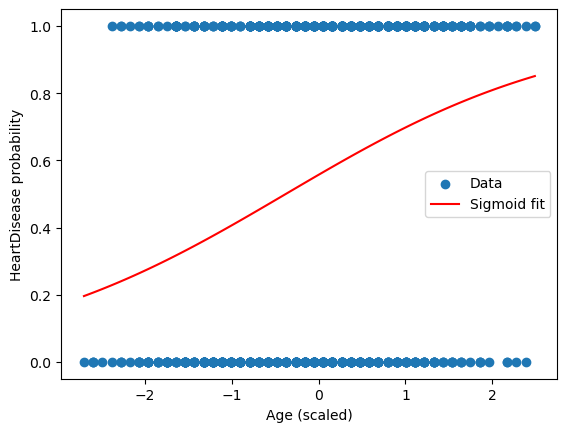

In [15]:
X_age = data[['Age']].values  # Only Age
y_target = y

# Scale Age
X_mean_age = X_age.mean(axis=0)
X_std_age = X_age.std(axis=0)
X_scaled_age = (X_age - X_mean_age)/X_std_age

# Train
model_age = LogisticRegressionScratch(learning_rate=0.5, iterations=5000)
model_age.fit(X_scaled_age, y_target)

# Plot smooth curve
X_plot = np.linspace(X_scaled_age.min(), X_scaled_age.max(), 100).reshape(-1,1)
y_prob = model_age.predict_proba(X_plot)

plt.scatter(X_scaled_age, y_target, label="Data")
plt.plot(X_plot, y_prob, color='red', label="Sigmoid fit")
plt.xlabel("Age (scaled)")
plt.ylabel("HeartDisease probability")
plt.legend()
plt.show()


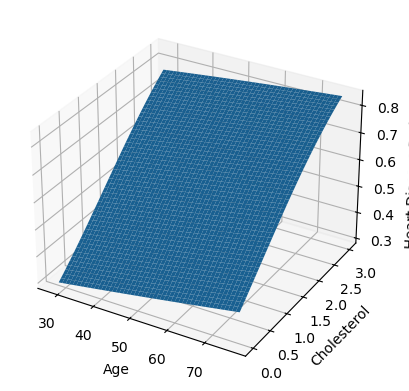

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


data = pd.read_csv("C:/Users/hp/Desktop/Everything/Work/Projects/classification problems/heart.csv")

# Encode categorical variables
data['Sex'] = data['Sex'].map({'M':0, 'F':1})
data['ChestPainType'] = data['ChestPainType'].map({'ATA':0, 'NAP':1, 'ASY':2, 'TA':3})
data['RestingECG'] = data['RestingECG'].map({'Normal':0, 'ST':1, 'LVH':2})
data['ExerciseAngina'] = data['ExerciseAngina'].map({'N':0, 'Y':1})
data['ST_Slope'] = data['ST_Slope'].map({'Up':0, 'Flat':1, 'Down':2})

# Features and target
X = data.drop(['HeartDisease'], axis=1).values
y = data['HeartDisease'].values

# Scale
X_mean = X.mean(axis=0)
X_std = X.std(axis=0)
X_scaled = (X - X_mean) / X_std

# Logistic Regression
class LogisticRegressionScratch:
    def __init__(self, lr=0.5, iterations=5000):
        self.lr = lr
        self.iterations = iterations

    def sigmoid(self, z):
        return 1 / (1 + np.exp(-z))

    def fit(self, X, y):
        m, n = X.shape
        X = np.c_[np.ones((m,1)), X]
        self.theta = np.zeros(n+1)

        for _ in range(self.iterations):
            z = X @ self.theta
            h = self.sigmoid(z)
            grad = (1/m) * (X.T @ (h - y))
            self.theta -= self.lr * grad

    def predict_proba(self, X):
        m = X.shape[0]
        X = np.c_[np.ones((m,1)), X]
        return self.sigmoid(X @ self.theta)

# Train
model = LogisticRegressionScratch()
model.fit(X_scaled, y)

# ---- 3D SURFACE ----

age_idx = 0
chol_idx = 2

age_vals = np.linspace(X[:,age_idx].min(), X[:,age_idx].max(), 50)
chol_vals = np.linspace(X[:,chol_idx].min(), X[:,chol_idx].max(), 50)

Age_grid, Chol_grid = np.meshgrid(age_vals, chol_vals)

# Create input grid
grid = np.tile(X_mean, (Age_grid.size, 1))
grid[:, age_idx] = Age_grid.ravel()
grid[:, chol_idx] = Chol_grid.ravel()

# Scale
grid_scaled = (grid - X_mean) / X_std

# Predict
Z = model.predict_proba(grid_scaled)
Z = Z.reshape(Age_grid.shape)

# Plot
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

ax.plot_surface(Age_grid, Chol_grid, Z)

ax.set_xlabel("Age")
ax.set_ylabel("Cholesterol")
ax.set_zlabel("Heart Disease Probability")

plt.show()
